# Introduction to Machine Learning

To apply today's course, we will analyze together examples of projects involving the development of Machine Learning algorithms. We will then see a complete case of ML including data cleaning, modeling and evaluation.

Up to you! And remember, don't get stuck, search, ask questions, have fun! We are all here to learn and practice.

## 1) Application case

In this exercise, you have minutes of kick-off meetings for projects involving machine learning. You need to determine:
- Are we talking about a supervised or unsupervised problem?
- Is the data structured or unstructured?
- Is it a regression or classification problem? Neither of the two ?
- What are the features and what is the target?
- What other feature ideas do you have in mind for the given problem?

Feel free to brainstorm as a group.

a) Sales prediction: The goal of the project is to predict the sales of a perfume shop to adjust the stock accordingly. The shop organizes events both in person and on social networks. Its sales are very sensitive to the season and the weather. The company can easily provide its sales data and the planning of its physical events, on the other hand we must go and retrieve the other information if necessary.

1. Supervised
2. Structured
3. Regression 
4. Target: Chiffres de Vente / Features: Season, Weather, (historical sales data), Event type (In person, Social Network)
5. Special/Unexpected Events (in further release)

b) Detection of the risk of default: The aim of the project is to detect if a person is at risk of not being able to repay his loan. This will save time to focus only on the most contentious cases. Loan data and subscriber data are already in the database.

1. Supervised
2. Structured (sales date), Unstructured / non existing (customers data)
3. Classification
4. Target: At risk or Not / Features: Loan data, Subscriber data
5. Net Incomes, Debt %age, Address, Age, Sex, Contract Type

c) Customer segmentation: The company delivers vegetable baskets. The goal of the project is to get to know their customers better by grouping them according to their characteristics. They will be able to think about how to improve the experience of each customer profile. They send us their basket sales data and we asked for whatever information they could have on their customers (in progress).

1. Unsupervised
2. Structured
3. Classification
4. Target: Customer Type / Features: Sales data, customer data (not received yet)
5. Genre, age, address, type (company, person)

d) Fracture diagnostics: The company is a radiology practice and wishes to have an algorithm for detecting the type of fracture. There are 7 types of fractures (transverse, longitudinal, displaced oblique, non-displaced oblique, greenstick, comminuted, spiral). From the radio, it is not always obvious and some are rare. This is why based on all the x-rays and their confirmed diagnoses, we want to develop an algorithm.

1. Supervised
2. Unstructured
3. Classification
4. Target: Fracture Type / Features: Historique de radios (radio + diagnostic)
5. Caractéristiques de chaque type de fracture (vérifier si quantifiable avec les médecins)

## 2) Data Cleaning

A jewelry company comes up with an idea to help sales associates identify customers with the highest purchasing potential. For this, according to their internal criteria, they were able to collect purchasing information from their customers and assign them a category between *occasional*, *frequent* and *vip* . Vip designates the most important customers, *frequent* the regulars and occasional the remaining customers.

As a Data Analyst, you are asked to prepare data for the creation of a machine learning algorithm. Thus, for customers that are not yet categorized, it will suffice to use the algorithm to predict their categories and thus adapt the level of service accordingly.

#### Identifying the problem

In [708]:
import pandas as pd
# Import shared functions
import sys
import os
shared_path = os.path.abspath(os.path.join(os.getcwd(), "../Shared"))
if shared_path not in sys.path:
    sys.path.append(shared_path)
import functions

a) Download the `customer_segmentation.csv` file at this [address](https://drive.google.com/file/d/1vnwPLcHcsrbZScKEG8yD4oPOVUyGHDTB/view?usp=sharing) and load the data in a `df` variable

The data has 9 columns:
- country: the customer's country of origin
- client_type(customer_type): the importance category of the customer
- average_basket: the average number of items purchased by the customer rounding up
- average_price: the average price spent by the customer rounding up
- visit_number: the number of visits made by the customer to the store
- age: the age of the customer
- gender: the customer's gender
- hobbies: leisure activities declared by the client
- customer_id: the internal unique identifier of the customer

In [709]:
df = pd.read_csv("customer_segmentation.csv")
df.head()
#df.describe()

,country,client_type,average_basket,average_price,visit_number,age,gender,hobbies,customer_id
0,it,occasional,2.0,756.0,2.0,46.0,female,NaN,0
1,uk,occasional,3.0,6229.0,1.0,66.0,male,NaN,1
2,fr,occasional,1.0,1803.0,2.0,64.0,male,NaN,2
3,fr,occasional,1.0,1857.0,3.0,52.0,male,NaN,3
4,fr,occasional,1.0,1761.0,2.0,58.0,male,NaN,4


b) Qualify the type of machine learning problem you are facing and identify the features and the target variable.

**Supervised classification** (assign one predefined category based on available features).<br>**Features:** country (qualitatif), average_basket (quantitatif), average_price (quantitatif), visit_number (quantitatif), age (quantitatif), gender (qualitatif) and hobbies(qualitatif)<br>**Target variable** to predict: client_type (qualitatif)

c) What do you think of the `customer_id` column as a feature? Is it useful in your opinion? (No code to do)

d) Delete the `customer_id` column.

In [710]:
df.drop(columns=["customer_id"], inplace=True)
df.head()

,country,client_type,average_basket,average_price,visit_number,age,gender,hobbies
0,it,occasional,2.0,756.0,2.0,46.0,female,NaN
1,uk,occasional,3.0,6229.0,1.0,66.0,male,NaN
2,fr,occasional,1.0,1803.0,2.0,64.0,male,NaN
3,fr,occasional,1.0,1857.0,3.0,52.0,male,NaN
4,fr,occasional,1.0,1761.0,2.0,58.0,male,NaN


#### Removing nonsensical values

e) From the .info() method of a Dataframe, determine which column(s) have missing information? What are text (object) type columns?

In [711]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         9000 non-null   object 
 1   client_type     9000 non-null   object 
 2   average_basket  9000 non-null   float64
 3   average_price   8536 non-null   float64
 4   visit_number    9000 non-null   float64
 5   age             8820 non-null   float64
 6   gender          8901 non-null   object 
 7   hobbies         887 non-null    object 
dtypes: float64(4), object(4)
memory usage: 562.6+ KB


f) Before dealing with missing values, it is always important to check the orders of magnitude of the numerical columns and see if there are any outliers. From a Dataframe's .describe() method, determine outlier cases

In [712]:
df.describe()

,average_basket,average_price,visit_number,age
count,9000.000000,8536.000000,9000.000000,8820.000000
mean,2.268667,4869.591495,4.811222,55.069501
std,1.557947,4098.673605,5.101245,10.186070
min,1.000000,-1.000000,1.000000,18.000000
25%,1.000000,1807.000000,2.000000,48.000000
50%,2.000000,2926.000000,3.000000,55.000000
75%,3.000000,6997.250000,7.000000,62.000000
max,12.000000,28137.000000,33.000000,87.000000


g) [more difficult] Delete rows whose `average_price` column values ​​are absurd in your opinion. Consider using panda masking techniques. **Be careful not to delete the null values ​​that we will then process** As a reminder, to determine the null values ​​of the column we can use `df.average_price.isnull()`

In [713]:
display(df.average_price.value_counts().sort_index())
# Delete rows with average_price = 0 or negative
print(f"len(df): {len(df)}")
mask = df.average_price > 0
# Add .copy() to make sure that df_cleaned is a copy, not a view
df_cleaned = df.loc[mask, :].copy()
print(f"len(df_cleaned): {len(df_cleaned)}")

-1.0        231
 191.0        1
 197.0        1
 206.0        2
 209.0        1
           ... 
 26014.0      1
 26306.0      1
 27383.0      1
 27818.0      1
 28137.0      1
Name: average_price, Length: 5053, dtype: int64

len(df): 9000
len(df_cleaned): 8305


#### Handling missing values

h) To replace missing values, one must first ensure that they do not represent a large part of the data. Calculate the proportion of missing values ​​per column.

In [714]:
def display_missing_values_rate():
    percent_missing = df_cleaned.isna().sum() * 100 / len(df_cleaned)
    display(percent_missing)

display_missing_values_rate()

country            0.000000
client_type        0.000000
average_basket     0.000000
average_price      0.000000
visit_number       0.000000
age                2.059001
gender             1.035521
hobbies           90.114389
dtype: float64

i) What do you think of the `hobbies` column? Can it be kept?

In [715]:
display(df_cleaned.hobbies.value_counts().sort_index())

movies      262
reading     245
sport       240
theaters     74
Name: hobbies, dtype: int64

j) Delete the `hobbies` column

In [716]:
df_cleaned.drop(columns=["hobbies"], inplace=True)

k) What strategy(ies) can you consider to replace missing values ​​in the `average_price`, `age` and `gender` columns?

**average_price - age:** replace by the average value<br>**gender:** set to "Unknown"

l) Replace the missing values ​​in the `gender` column with the mode. For that, see how to calculate mode and then parse pandas [fillna](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html) function.

In [717]:
df_cleaned.gender.fillna(
    value=df_cleaned.gender.mode()[0],
    inplace=True,
)

functions.show_unique_values(df_cleaned.gender)

2 possible values: ['female' 'male']


m) Replace the missing values ​​in the `average_price` and `age` columns with their respective means.

In [718]:
df_cleaned.average_price.fillna(
    value=df_cleaned.average_price.mean(),
    inplace=True,
)

df_cleaned.age.fillna(
    value=df_cleaned.average_price.mean(),
    inplace=True,
)

n) Verify that your Data Frame no longer contains any missing values.

In [719]:
display_missing_values_rate()
df_cleaned.head()

country           0.0
client_type       0.0
average_basket    0.0
average_price     0.0
visit_number      0.0
age               0.0
gender            0.0
dtype: float64

,country,client_type,average_basket,average_price,visit_number,age,gender
0,it,occasional,2.0,756.0,2.0,46.0,female
1,uk,occasional,3.0,6229.0,1.0,66.0,male
2,fr,occasional,1.0,1803.0,2.0,64.0,male
3,fr,occasional,1.0,1857.0,3.0,52.0,male
4,fr,occasional,1.0,1761.0,2.0,58.0,male


#### Separation between features and target

o) Put the features in an `X` variable and the target column in a `y` variable

In [720]:
features_columns = [
    "country",
    "average_basket",
    "average_price",
    "visit_number",
    "age",
    "gender",
]
x = df_cleaned[features_columns]

target_columns = [
    "client_type"
]
y = df_cleaned[target_columns]

display(x)
display(y)

,country,average_basket,average_price,visit_number,age,gender
0,it,2.0,756.0,2.0,46.0,female
1,uk,3.0,6229.0,1.0,66.0,male
2,fr,1.0,1803.0,2.0,64.0,male
3,fr,1.0,1857.0,3.0,52.0,male
4,fr,1.0,1761.0,2.0,58.0,male
...,...,...,...,...,...,...
8995,uk,2.0,6346.0,1.0,67.0,male
8996,it,2.0,1316.0,3.0,45.0,male
8997,fr,1.0,1956.0,3.0,43.0,female
8998,fr,1.0,1381.0,3.0,60.0,male


,client_type
0,occasional
1,occasional
2,occasional
3,occasional
4,occasional
...,...
8995,occasional
8996,occasional
8997,occasional
8998,occasional


#### Convert text to numeric columns

#### The target variable

o) Transform `y` to values ​​0, 1 and 2 with sklearn's [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) tool. Check and view classes.

In [721]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

le = LabelEncoder()
le.fit(y.client_type)
y = le.transform(y.client_type)
display(y)

unique, counts = np.unique(y, return_counts=True)
dict(zip(unique, counts))

array([1, 1, 1, ..., 1, 1, 1])

{0: 2009, 1: 5726, 2: 570}

The classes are transformed by their index in alphabetical order, 0 for the first, 1 for the next ....

#### Features

p) In a new `X_dummy` variable, transform the text of the `country` and `gender` columns with the tool [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing/OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder) from sklearn. Then display the categories. **Add sparse=False in parameters of OneHotEncoder()**

In [722]:
from sklearn.preprocessing import OneHotEncoder

# To only keep the qualitative features, only keep country and gender from the x DataFrame
qualitative_features = x[["country", "gender"]]
encoder = OneHotEncoder(sparse_output=False)
X_dummy = encoder.fit(qualitative_features)
display(X_dummy.categories_)

[array(['fr', 'it', 'uk'], dtype=object),
 array(['female', 'male'], dtype=object)]

q) What does this statement do?

In [723]:
dummy_cols = np.concatenate((X_dummy.categories_[0], X_dummy.categories_[1]), axis=None)
print(dummy_cols)

['fr' 'it' 'uk' 'female' 'male']


r) Transform X_dummy into a DataFrame object with the correct column names using the previous question.

In [ ]:
X_dummy = encoder.transform(x[["country", "gender"]])
X_dummy_df = pd.DataFrame(X_dummy, columns=encoder.get_feature_names_out())
display(X_dummy_df)

array([[0., 1., 0., 1., 0.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.]])

,country_fr,country_it,country_uk,gender_female,gender_male
0,0.0,1.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...
8300,0.0,0.0,1.0,0.0,1.0
8301,0.0,1.0,0.0,0.0,1.0
8302,1.0,0.0,0.0,1.0,0.0
8303,1.0,0.0,0.0,0.0,1.0


#### Normalization

Now that our data no longer contains any text type data, we will normalize our numeric features.

s) In an `X_num` variable, normalize the values ​​of the `average_basket`, `average_price`, `visit_number` and `age` columns. You can use the [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) tool from sklearn.

In [725]:
from sklearn.preprocessing import StandardScaler

# To only keep the quantitative features, keep "average_basket", "average_price", "visit_number" and "age" from the x DataFrame
quantitative_features = x[["average_basket", "average_price", "visit_number", "age"]]
scaler = StandardScaler()
scaler.fit(quantitative_features)

X_num = scaler.transform(x[["average_basket", "average_price", "visit_number", "age"]])

t) Transform X_num into a DataFrame with the correct column names.

In [726]:
X_num_df = pd.DataFrame(X_num, columns=["average_basket", "average_price", "visit_number", "age"])
display(X_num_df)

,average_basket,average_price,visit_number,age
0,-0.167631,-1.043327,-0.551117,-0.157879
1,0.476596,0.300528,-0.747936,-0.129429
2,-0.811857,-0.786243,-0.551117,-0.132274
3,-0.811857,-0.772984,-0.354298,-0.149344
4,-0.811857,-0.796556,-0.551117,-0.140809
...,...,...,...,...
8300,-0.167631,0.329257,-0.747936,-0.128007
8301,-0.167631,-0.905823,-0.354298,-0.159301
8302,-0.811857,-0.748675,-0.354298,-0.162146
8303,-0.811857,-0.889862,-0.354298,-0.137964


#### Reconstruction of transformed features

s) Group the `X_dummy` and `X_num` variables into an `X` DataFrame with the correct column names. You can use pandas [concat](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.concat.html) function. **Pay attention to the axis parameter** then display the result.

In [727]:
X = pd.concat([X_dummy_df, X_num_df], axis=1)

You should get the following result:

In [728]:
X

,country_fr,country_it,country_uk,gender_female,gender_male,average_basket,average_price,visit_number,age
0,0.0,1.0,0.0,1.0,0.0,-0.167631,-1.043327,-0.551117,-0.157879
1,0.0,0.0,1.0,0.0,1.0,0.476596,0.300528,-0.747936,-0.129429
2,1.0,0.0,0.0,0.0,1.0,-0.811857,-0.786243,-0.551117,-0.132274
3,1.0,0.0,0.0,0.0,1.0,-0.811857,-0.772984,-0.354298,-0.149344
4,1.0,0.0,0.0,0.0,1.0,-0.811857,-0.796556,-0.551117,-0.140809
...,...,...,...,...,...,...,...,...,...
8300,0.0,0.0,1.0,0.0,1.0,-0.167631,0.329257,-0.747936,-0.128007
8301,0.0,1.0,0.0,0.0,1.0,-0.167631,-0.905823,-0.354298,-0.159301
8302,1.0,0.0,0.0,1.0,0.0,-0.811857,-0.748675,-0.354298,-0.162146
8303,1.0,0.0,0.0,0.0,1.0,-0.811857,-0.889862,-0.354298,-0.137964


**BRAVO** You have just cleaned the data!! They are now ready to be used to build a machine learning algorithm.

t) Summarize the steps taken and lessons learned as a memo.

- removal of unnecessary columns (customer_id)
- removal of absurd values ​​(negative values ​​of average_price)
- replacement of empty values (average for price and age, mode for sex)
- dummification of textual values ​​with labelencoder for target (client_type) and onehotencoder for features (country, gender)
- normalization of numerical features (average_basket, average_price, visit_number, age)
- concatenation of results in a single variable X

## 3) Modeling

u) From function [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) from sklearn and from `X` and `y`, generate the dataframes `X_train`, `X_test`, `y<_>train`, `y_test`. The training sample (train) will represent 70% of the initial data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
)

display(X_train)
display(X_test)

,country_fr,country_it,country_uk,gender_female,gender_male,average_basket,average_price,visit_number,age
8143,1.0,0.0,0.0,1.0,0.0,-0.811857,-0.567956,-0.551117,-0.164991
8199,1.0,0.0,0.0,1.0,0.0,-0.167631,0.543124,1.417074,-0.129429
3487,0.0,0.0,1.0,0.0,1.0,-0.167631,0.575536,-0.551117,-0.142231
5164,1.0,0.0,0.0,1.0,0.0,-0.811857,-0.866045,-0.551117,-0.156456
3454,0.0,0.0,1.0,0.0,1.0,1.120823,1.083809,-0.551117,-0.119472
...,...,...,...,...,...,...,...,...,...
5734,1.0,0.0,0.0,0.0,1.0,-0.811857,-0.652423,-0.747936,-0.142231
5191,1.0,0.0,0.0,0.0,1.0,-0.811857,-0.724858,-0.157479,-0.120895
5390,1.0,0.0,0.0,0.0,1.0,-0.811857,-0.809079,-0.747936,-0.132274
860,0.0,0.0,1.0,0.0,1.0,1.120823,0.268117,-0.551117,-0.136542


array([1, 0, 1, ..., 1, 1, 1])

,country_fr,country_it,country_uk,gender_female,gender_male,average_basket,average_price,visit_number,age
4503,0.0,0.0,1.0,0.0,1.0,1.120823,0.638640,-0.747936,-0.145076
2118,0.0,0.0,1.0,0.0,1.0,1.120823,0.448099,-0.551117,-0.109515
7314,1.0,0.0,0.0,1.0,0.0,-0.811857,-0.681888,-0.551117,-0.136542
3442,1.0,0.0,0.0,1.0,0.0,-0.811857,-0.819637,-0.354298,-0.142231
2698,1.0,0.0,0.0,0.0,1.0,-0.167631,-0.994464,-0.747936,-0.125162
...,...,...,...,...,...,...,...,...,...
2095,1.0,0.0,0.0,0.0,1.0,0.476596,0.384504,-0.551117,-0.140809
4190,1.0,0.0,0.0,1.0,0.0,-0.167631,-0.798521,-0.551117,-0.163568
1357,1.0,0.0,0.0,0.0,1.0,1.120823,0.225883,0.039340,-0.146499
5553,0.0,1.0,0.0,1.0,0.0,-0.811857,-0.868500,-0.747936,-0.122317


array([1, 1, 1, ..., 0, 1, 0])

v) From sklearn, create a model like [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.score) and train le on your training data with the `fit` method.

In [730]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42, max_depth=5)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

w) From the `score` method of the model, display the score on the training data and the test data. What do you notice ?

In [731]:
y_pred = clf.predict(X_test)
dict_client_type_mapping = {
    0: "frequent",
    1: "occasional",
    2: "vip",
}
values = [dict_client_type_mapping[pred] for pred in y_pred]

print(f"Training data accuracy : {clf.score(X_train, y_train)}")
print(f"Test data accuracy : {clf.score(X_test, y_test)}")

Training data accuracy : 0.9827971787373129
Test data accuracy : 0.978330658105939


## 4) Prediction

x) Download the file `customer_segmentation_new.csv` at this [address](https://drive.google.com/file/d/1dbveJ9Urk7KQ4RaDynXD4wKLpNZ6U6yY/view?usp=sharing) in a variable ` df_new`. This file corresponds to new customers who do not yet have categories.
- Apply the same transformations as before to obtain a dataframe `X_new` which will correspond to the transformed version of `df_new` (Help yourself from your answer to question t so as not to forget steps )
- From X_new and your previously trained model, predict the vector `y_predict` corresponding to the categorization of each of these new customers

**Warning**: It is important to keep the same transformations as in training. For example, an imputation by the mean should be imputed by the same mean as in training and not a new mean. Similarly for transformations requiring a `fit_transform`, in the prediction phase only the `transform` is necessary.

In [732]:
df_new = pd.read_csv("customer_segmentation_new.csv")
# print(df_new.info())
# print(df_new.describe())
#display(df_new)

""" Clean-up """
# Drop useless columns
df_new.drop(columns=["hobbies", "customer_id"], inplace=True)

# Remove rows with outlier average_price
mask = df_new["average_price"] >= 0
df_new = df_new[mask]

# Fill in null values for average_price, age, gender
df_new.average_price.fillna(value=df_new.average_price.mean(), inplace=True)
df_new.age.fillna(value=df_new.age.mean(), inplace=True)
df_new.gender.fillna(value=df_new.gender.mode()[0], inplace=True)

In [733]:
""" Feature pre-processing """
# Dummification of country and gender
qualitative_features = df_new[["country", "gender"]]
#encoder has already been fit(), only use transform()
qualitative_dummy = encoder.transform(qualitative_features)

# Normalization for average_basket, average_price, visit_number and age
quantitative_features = df_new[
    ["average_basket", "average_price", "visit_number", "age"]
]
#scaler has already been fit(), only use transform()
quantitative_scaled = scaler.transform(quantitative_features)

X_new = pd.concat(
    [
        pd.DataFrame(
            qualitative_dummy,
            columns=encoder.get_feature_names_out(),
        ),
        pd.DataFrame(
            quantitative_scaled,
            columns=scaler.get_feature_names_out(),
        ),
    ],
    axis=1,
)

In [ ]:
""" Prediction """
y_predict = clf.predict(X_new)
# Add a new column to df_new, with the predicted customer_type
df_new["customer_type"] = [dict_client_type_mapping[pred] for pred in y_predict]
display(df_new.sample(30))

,country,average_basket,average_price,visit_number,age,gender,customer_type
790,uk,2.0,8198.0,2.0,68.000000,male,occasional
110,fr,1.0,2039.0,1.0,70.000000,male,occasional
861,fr,1.0,1909.0,1.0,54.675027,male,occasional
780,fr,1.0,1597.0,2.0,48.000000,male,occasional
633,uk,2.0,7925.0,2.0,49.000000,female,occasional
661,fr,1.0,909.0,3.0,53.000000,male,occasional
253,fr,2.0,7400.0,6.0,52.000000,female,frequent
710,it,1.0,1476.0,2.0,57.000000,male,occasional
294,fr,2.0,1702.0,2.0,66.000000,male,occasional
385,uk,3.0,6910.0,1.0,74.000000,female,occasional


## 5) [Bonus] Optimization

y) From sklearn's [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) class, perform a grid search of your previous model .
You will perform a grid search with a 3 fold cross validation parameter and the hyperparameter grid will be as follows.

`params = {
    'min_samples_split': [0.001, 0.01, 0.1, 0.2, 0.5],
    "max_depth": [2, 5,10, None]
}`

In [735]:
from sklearn.model_selection import GridSearchCV

params = {
    "min_samples_split": [0.001, 0.01, 0.1, 0.2, 0.5],
    "max_depth": [2, 5, 10, None],
}

grid_search_clf = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=3,
)
grid_search_clf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [2, 5, 10, None],
                         'min_samples_split': [0.001, 0.01, 0.1, 0.2, 0.5]})

z) Display the best hyperparameters determined by the grid search.

In [736]:
print(f"Best parameters: {grid_search_clf.best_params_}")
print(f"Best cross-validation score: {grid_search_clf.best_score_:.3f}")
print(f"Train set score: {grid_search_clf.score(X_train, y_train):.3f}")

Best parameters: {'max_depth': 10, 'min_samples_split': 0.001}
Best cross-validation score: 0.988
Train set score: 0.998


a_bis) From the `score` method of the grid-searched model, display the score on the training data and the test data. What do you notice about the score of the non-grid-searched model?

In [737]:
print(f"Train set score grid-searched model: {grid_search_clf.score(X_train, y_train):.3f}")
print(f"Test set score grid-searched model: {grid_search_clf.score(X_test, y_test):.3f}")

print(f"Train set score non-grid-searched model: {clf.score(X_train, y_train):.3f}")
print(f"Test set score non-grid-searched model: {clf.score(X_test, y_test):.3f}")

Train set score grid-searched model: 0.998
Test set score grid-searched model: 0.991
Train set score non-grid-searched model: 0.983
Test set score non-grid-searched model: 0.978


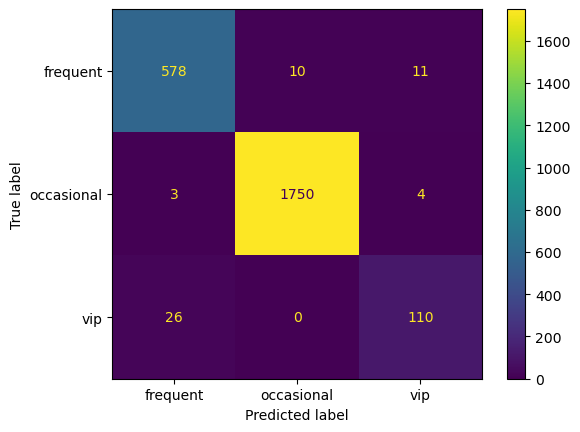

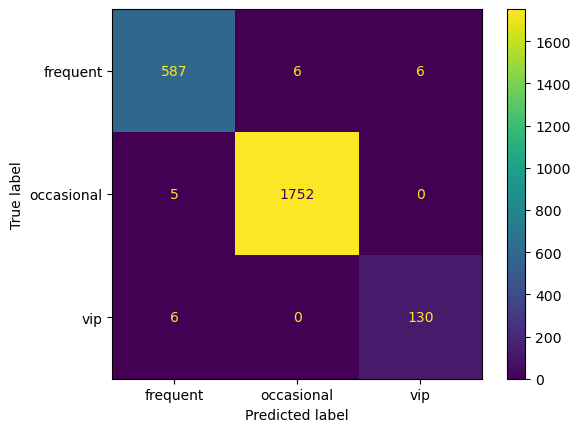

In [738]:
# Bonus: voir les erreurs sur une matrice de confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["frequent", "occasional", "vip"]
)
disp.plot()

y_pred = grid_search_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["frequent", "occasional", "vip"]
)
disp.plot()